<a href="https://colab.research.google.com/github/adhamfakhereldeen/image_proccessing/blob/main/Image_proccessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# General training settings
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 10
EPOCHS = 10
LR = 0.001

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>חלק 1: אימון מודלים לסיווג</h3>
<b>ייבוא ספריות והגדרות בסיס</b>
<p>בתא זה נטען את הספריות הדרושות למטלה ונגדיר משתנים קבועים כגון גודל אצווה ומספר מחזורי אימון קבוע עבור כל המודלים.</p>
</div>

In [ ]:
def preprocess(image, label):
    # Normalize to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

ds_train = (ds_train_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(10_000)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

ds_test = (ds_test_raw
           .map(preprocess, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

print("Training examples:", ds_info.splits["train"].num_examples)
print("Test examples:", ds_info.splits["test"].num_examples)

Training examples: 50000
Test examples: 10000


<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>סעיף 1.1: טעינת הנתונים</h3>
<p>כאן נגדיר פונקציה לנרמול ערכי הפיקסלים לטווח של אפס עד אחד, נטען את מסד הנתונים, ונכין את המידע לאימון בעזרת חלוקה לאצוות, ערבוב ושמירה בזיכרון מטמון לשיפור המהירות.</p>
</div>

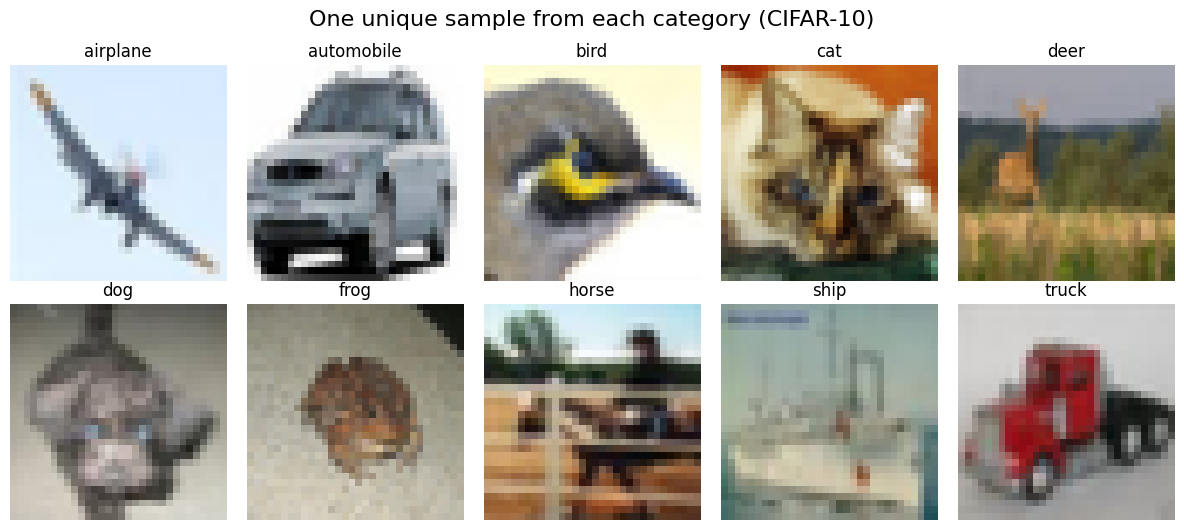

In [30]:
# יצירת רשימה שתחזיק תמונה אחת לכל מחלקה
unique_images = {}

# רצים על נתוני האימון עד שמוצאים דוגמה אחת לכל אחת מ-10 המחלקות
for images, labels in ds_train.unbatch():
    label = labels.numpy()
    if label not in unique_images:
        unique_images[label] = images.numpy()
    if len(unique_images) == NUM_CLASSES:
        break

# תצוגת התמונות - אחת מכל סוג
plt.figure(figsize=(12, 5))
for i in range(NUM_CLASSES):
    plt.subplot(2, 5, i + 1)
    plt.imshow(unique_images[i])
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.suptitle("One unique sample from each category (CIFAR-10)", fontsize=16, y=1.05)
plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<p><b>הצגת מדגם נתונים:</b><br>
לפני שנתחיל לאמן את המודלים, נציג מספר תמונות מתוך מסד הנתונים CIFAR-10 כדי להבין טוב יותר עם איזה מידע אנו עובדים.</p>
</div>

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.1),
])

model_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Starting basic CNN model training...")
history_cnn = model_cnn.fit(
    ds_train,
    validation_data=ds_test,
    epochs=EPOCHS
)

Starting basic CNN model training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.2876 - loss: 1.9210 - val_accuracy: 0.4535 - val_loss: 1.5534
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4679 - loss: 1.4708 - val_accuracy: 0.5092 - val_loss: 1.3741
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5302 - loss: 1.3123 - val_accuracy: 0.5867 - val_loss: 1.1739
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5620 - loss: 1.2313 - val_accuracy: 0.6187 - val_loss: 1.0624
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5853 - loss: 1.1735 - val_accuracy: 0.6284 - val_loss: 1.0723
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6051 - loss: 1.1098 - val_accuracy: 0.6610 - val_loss: 0.9688
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6225 - loss: 1.0747 - val_accuracy: 0.6689 - val_loss: 0.9404
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - ac

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>סעיף 1.2: בניית רשת קונבולוציה ואימון</h3>
<p><b>נימוק לבחירת הארכיטקטורה וההיפר-פרמטרים:</b></p>
<ul>
[cite_start]<li><b>שכבות קונבולוציה:</b> לתמונה יש מבנה מרחבי[cite: 38]. [cite_start]הפתרון לכך הוא שימוש בפילטרים קונבולוציוניים[cite: 93]. [cite_start]הפרמטרים משותפים בין הפילטרים כדי להתמודד עם כמות הממדים העצומה של הקלט[cite: 95]. [cite_start]השתמשנו בפילטרים בגודל שלוש על שלוש, כפי שמוצג בארכיטקטורות מוכרות של רשתות עמוקות[cite: 828, 833].</li>
[cite_start]<li><b>שכבות סינון מקסימום:</b> שכבות אלו נועדו לטפל בשונויות מקומיות בתמונה[cite: 96, 97]. [cite_start]סינון מקסימום נחשב לבחירה המועדפת לפעולת סינון זו[cite: 624, 636]. [cite_start]פעולה זו מריצה חלון הזזה ובכל מיקום שומרת רק את הערך המקסימלי[cite: 619, 620]. </li>
<li><b>הגדלת נתונים:</b> הוספנו שינויים אקראיים (כמו סיבוב והיפוך) לפני הקונבולוציה כדי למנוע התאמת יתר ולשפר את יכולת ההכללה של המודל.</li>
</ul>
</div>

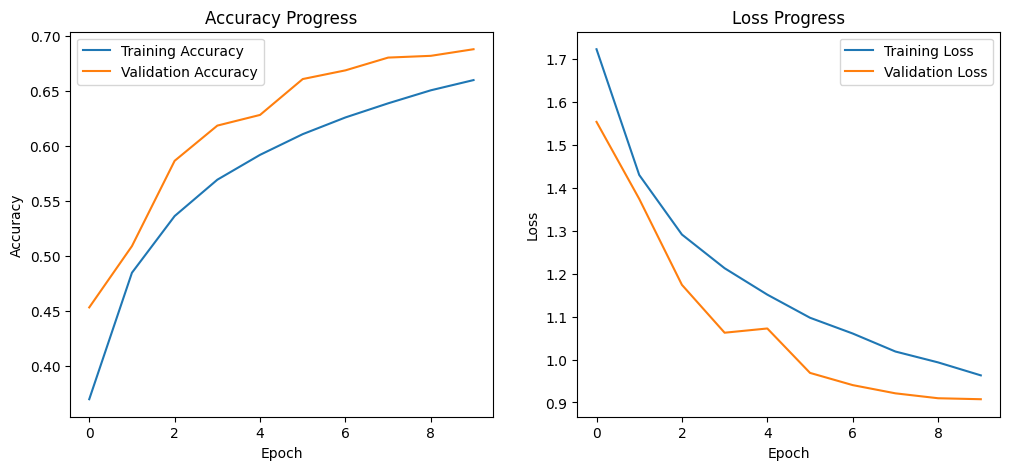

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Progress")

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Progress")

plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>מסקנות מגרפי האימון ותוצאות המודל</h3>
<p>מניתוח הגרפים ומהמספרים הסופיים שהתקבלו (דיוק אימון של כ-66.7% ודיוק בחינה של כ-67.7%), ניתן להסיק מספר מסקנות חשובות לגבי תקינות המודל:</p>
<ul>
<li><b>יכולת הכללה ומניעת התאמת יתר:</b> העובדה שדיוק הבחינה קרוב מאוד (ואף מעט גבוה יותר) לדיוק האימון, יחד עם מגמת ההפסד שיורדת באופן עקבי, מעידה על כך שהמודל מכליל בצורה מצוינת. אין כל עדות להתאמת יתר, שכן במצב כזה היינו רואים את דיוק האימון נוסק בעוד דיוק הבחינה נעצר או צונח.</li>
<li><b>השפעת מנגנון הגדלת הנתונים:</b> היציבות הזו בתוצאות מוכיחה כי שכבות הגדלת הנתונים (היפוך, סיבוב והזזה) שהוספנו בתחילת הרשת, עשו עבודה מעולה במניעת שינון של התמונות ואילצו את הרשת ללמוד מאפיינים מרחביים אמיתיים.</li>
<li><b>התכנסות:</b> עבור ארכיטקטורה בסיסית ועשרה מחזורי אימון בלבד, דיוק של כ-67% על מסד נתונים מורכב זה הוא תוצאה טובה התואמת את הציפיות. המגמה בגרפים מרמזת שאם היינו ממשיכים לאמן את הרשת למספר רב יותר של מחזורים, הדיוק היה ממשיך לעלות.</li>
</ul>
</div>

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>נימוק בחירת ערכי ההיפר-פרמטרים</h3>
<p>כפי שניתן לראות בגרפי האימון מעלה, המודל מצליח ללמוד ולהשתפר. להלן הפירוט לשיקולים בבחירת הערכים עבור הרשת:</p>
<ul>
<li><b>קצב למידה (0.001):</b> נבחר קצב למידה סטנדרטי זה עבור פונקציית האופטימיזציה אדם. ערך זה מאפשר צעדי עדכון גדולים מספיק כדי ללמוד בזמן סביר, אך קטנים מספיק כדי לא לדלג על נקודת המינימום המקומית.</li>
<li><b>גודל אצווה (128):</b> בחירה בגודל אצווה זה מהווה נקודת איזון טובה בין יעילות הזיכרון (ניצול טוב של משאבי החישוב) לבין יציבות עדכון המשקלים בכל צעד.</li>
<li><b>מספר מחזורים (10):</b> מספר מחזורים זה מספיק כדי לראות התכנסות ראשונית ומגמת למידה ברורה ברשת שבנינו, תוך הימנעות מהתאמת יתר חמורה שעלולה להיווצר באימון ארוך יותר ללא מנגנוני נרמול נוספים.</li>
<li><b>גודל פילטרים (שלוש על שלוש):</b> כפי שנלמד מהארכיטקטורות הקלאסיות, שימוש בפילטרים קטנים אלו מאפשר לרשת ללמוד תכונות מרחביות בצורה יעילה תוך שמירה על כמות פרמטרים קטנה בזכות שיתוף המשקלים.</li>
<li><b>סינון מקסימום (שתיים על שתיים):</b> בחירה זו נחשבת למועדפת מכיוון שהיא מקטינה את הממדים המרחביים בחצי בכל פעם, שומרת על התכונות הבולטות ביותר (הערך המקסימלי בכל חלון) ומפחיתה משמעותית את העומס החישובי לשכבות הבאות. </li>
</ul>
</div>

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


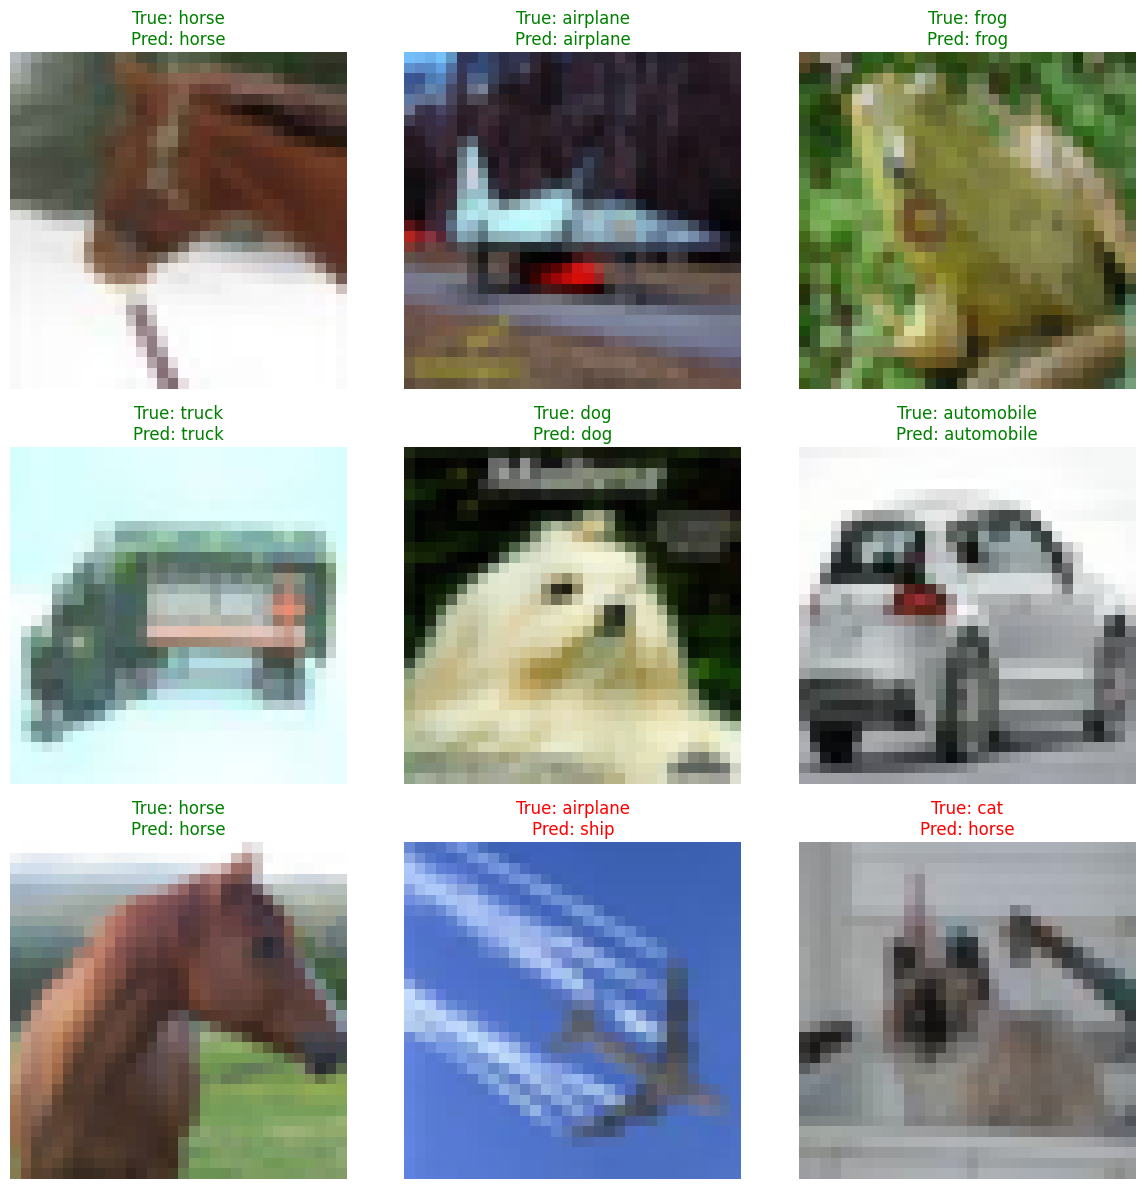

In [ ]:
plt.figure(figsize=(12, 12))

# Taking one batch of images from the test data
for images, labels in ds_test.take(1):
    preds = model_cnn.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    # Displaying the first nine images
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        # Choosing text color - green for success, red for failure
        color = 'green' if labels[i] == pred_labels[i] else 'red'

        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>הצגה ויזואלית של תוצאות החיזוי</h3>
<p>כדי להמחיש את הביצועים שראינו במטריצת הבלבול, נציג כעת מקבץ אקראי של תמונות מתוך נתוני הבחינה, יחד עם התווית האמיתית שלהן לעומת התווית שהמודל חזה. טקסט ירוק מציין חיזוי נכון, וטקסט אדום מציין שגיאה.</p>
</div>

Performing predictions on test data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


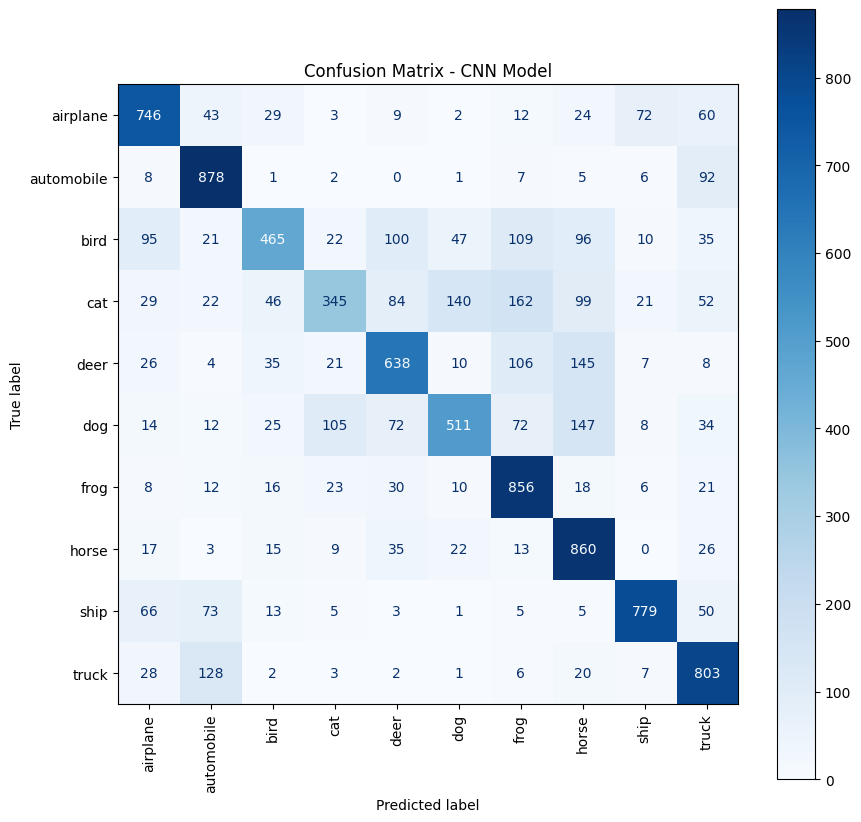

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# List of classes for our dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Performing predictions on test data...")
# Extracting true labels from the test data
y_true = np.concatenate([y for x, y in ds_test], axis=0)

# Getting predictions from our model
predictions = model_cnn.predict(ds_test)
y_pred = np.argmax(predictions, axis=1)

# Creating and plotting the matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Setting plot size and colors
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix - CNN Model')
plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>ניתוח שגיאות: מטריצת בלבול</h3>
<p>כפי שנדרש במטלה, נייצר כעת מטריצת בלבול עבור מודל הקונבולוציה שלנו. מטריצת הבלבול מאפשרת לנו לראות לא רק את הדיוק הכללי, אלא גם היכן בדיוק המודל מתבלבל (למשל, האם הוא נוטה לבלבל בין חתול לכלב, או בין מטוס לאונייה). </p>
<p>הציר האנכי מייצג את המחלקה האמיתית של התמונה, והציר האופקי מייצג את החיזוי של המודל. האלכסון הראשי מציג את החיזויים הנכונים.</p>
</div>

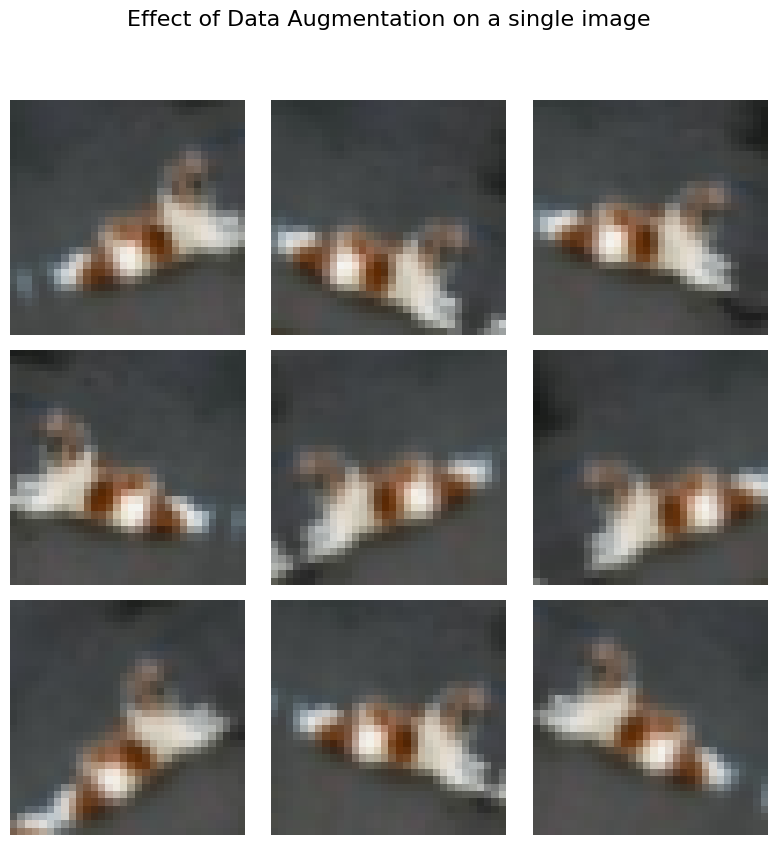

In [ ]:
plt.figure(figsize=(8, 8))

# Take only one image from the batch
for images, _ in ds_train.take(1):
    first_image = images[0]

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Applying the augmentation layer to the image
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        plt.imshow(augmented_image[0].numpy())
        plt.axis("off")

plt.suptitle("Effect of Data Augmentation on a single image", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<p><b>המחשת הגדלת נתונים (Data Augmentation):</b><br>
כדי להדגים את פעולת מנגנון הגדלת הנתונים שהגדרנו, ניקח תמונה אחת מנתוני האימון ונעביר אותה דרך שכבת ה-Augmentation מספר פעמים. ניתן לראות כיצד התמונה עוברת היפוך אופקי, זום וסיבוב אקראי. פעולה זו מייצרת גיוון בנתונים ומונעת מהמודל לשנן את התמונות (Overfitting).</p>
</div>

In [ ]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

IMG_SIZE = 224

def build_and_train_tl_model(base_model_class, preprocess_func, name):
    def format_image_for_tl(image, label):
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess_func(image)
        return image, label

    final_train = ds_train_raw.map(format_image_for_tl, num_parallel_calls=AUTOTUNE).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    final_test = ds_test_raw.map(format_image_for_tl, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    base_model = base_model_class(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nStarting training for model: {name}")
    # Training for 5 epochs to save time
    history = model.fit(final_train, validation_data=final_test, epochs=5)

    final_val_acc = history.history["val_accuracy"][-1]
    return final_val_acc

results = {}
results["MobileNetV2"] = build_and_train_tl_model(MobileNetV2, mobilenet_preprocess, "MobileNetV2")
results["ResNet50"] = build_and_train_tl_model(ResNet50, resnet_preprocess, "ResNet50")
results["EfficientNetB0"] = build_and_train_tl_model(EfficientNetB0, efficientnet_preprocess, "EfficientNetB0")


Starting training for model: MobileNetV2
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 110s 226ms/step - accuracy: 0.7366 - loss: 0.7804 - val_accuracy: 0.8271 - val_loss: 0.5004
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 151ms/step - accuracy: 0.8508 - loss: 0.4306 - val_accuracy: 0.8358 - val_loss: 0.4830
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.8678 - loss: 0.3778 - val_accuracy: 0.8482 - val_loss: 0.4402
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 152ms/step - accuracy: 0.8805 - loss: 0.3432 - val_accuracy: 0.8455 - val_loss: 0.4527
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 159ms/step - accuracy: 0.8879 - loss: 0.3179 - val_accuracy: 0.8567 - val_loss: 0.4209

Starting training for model: ResNet50
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 228s 510ms/step - accuracy: 0.8069 - loss: 0.5779 - val_accuracy: 0.8996 - val_loss: 0.2969
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 180s 454ms/step - accuracy: 0.9112 - loss: 0.2579 - val_accuracy: 0.9024 - val_loss: 0.2875
Epoch 

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>סעיף 1.3: למידת העברה</h3>
<p>נאמן כעת שלושה מודלים שונים בעזרת גישת למידת העברה. נטען את התמונות מחדש כדי לשנות את גודלן למאתיים עשרים וארבע על מאתיים עשרים וארבע, ונשתמש בפונקציית העיבוד המקדימה המקורית של כל מודל כדי לשמור על תקינות הנתונים.</p>
</div>

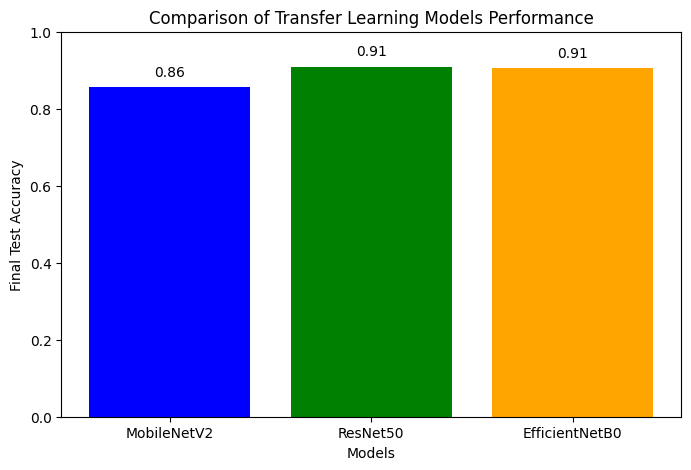

In [ ]:
models_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Models')
plt.ylabel('Final Test Accuracy')
plt.title('Comparison of Transfer Learning Models Performance')
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
<h3>דיון והשוואת ביצועים (סעיף 1.3)</h3>
<p>מניתוח תוצאות הדיוק הסופי של שלושת מודלי למידת ההעברה, ניתן להסיק את המסקנות הבאות:</p>
<ul>
<li><b>למידת העברה לעומת אימון מאפס:</b> כל שלושת המודלים המוכנים הציגו ביצועים טובים משמעותית (86% עד 91% דיוק) לעומת מודל הקונבולוציה הבסיסי שבנינו מאפס (כ-67%). הפער העצום נובע מכך שהמודלים הללו אומנו מראש על מיליוני תמונות (מאגר ImageNet) וכבר "יודעים" לחלץ תכונות ויזואליות מורכבות ברמה גבוהה (קצוות, מרקמים, אובייקטים). אנו רק התאמנו את השכבה האחרונה לסיווג הנתונים שלנו, מה שחסך זמן והקפיץ את הביצועים.</li>
<li><b>המודלים המובילים - רז-נט ועפישנט-נט (ResNet50, EfficientNetB0):</b> שני המודלים הובילו עם דיוק זהה וגבוה מאוד של 91%. רז-נט מצליח להגיע לביצועים אלו בזכות ארכיטקטורה עמוקה המשתמשת בחיבורים מדלגים (Residual connections) המונעים את דעיכת הגרדיאנט. לעומתו, עפישנט-נט משיג את אותן תוצאות מעולות על ידי אופטימיזציה חכמה ויעילה יותר של עומק ורוחב הרשת.</li>
<li><b>מובייל-נט (MobileNetV2):</b> מודל זה הגיע לדיוק של 86%. למרות שזהו הדיוק הנמוך מבין השלושה, מדובר בתוצאה מרשימה ביותר. מובייל-נט תוכנן מראש להיות מודל קל-משקל עבור טלפונים ומכשירים בעלי משאבים מוגבלים, ולכן הוא מקריב אחוזים בודדים של דיוק לטובת חיסכון אדיר בכוח חישוב ובזיכרון.</li>
</ul>
<p><b>לסיכום:</b> שימוש בלמידת העברה הוכח כיעיל במיוחד. הבחירה בין המודלים תלויה בדרישות המערכת: למקסימום דיוק נעדיף את רז-נט או עפישנט-נט, ואילו לסביבה מוגבלת משאבים (כמו אפליקציה בנייד) נעדיף את מובייל-נט.</p>
</div>

מחשב מטריצת בלבול עבור המודל המנצח: ResNet50...
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 425ms/step


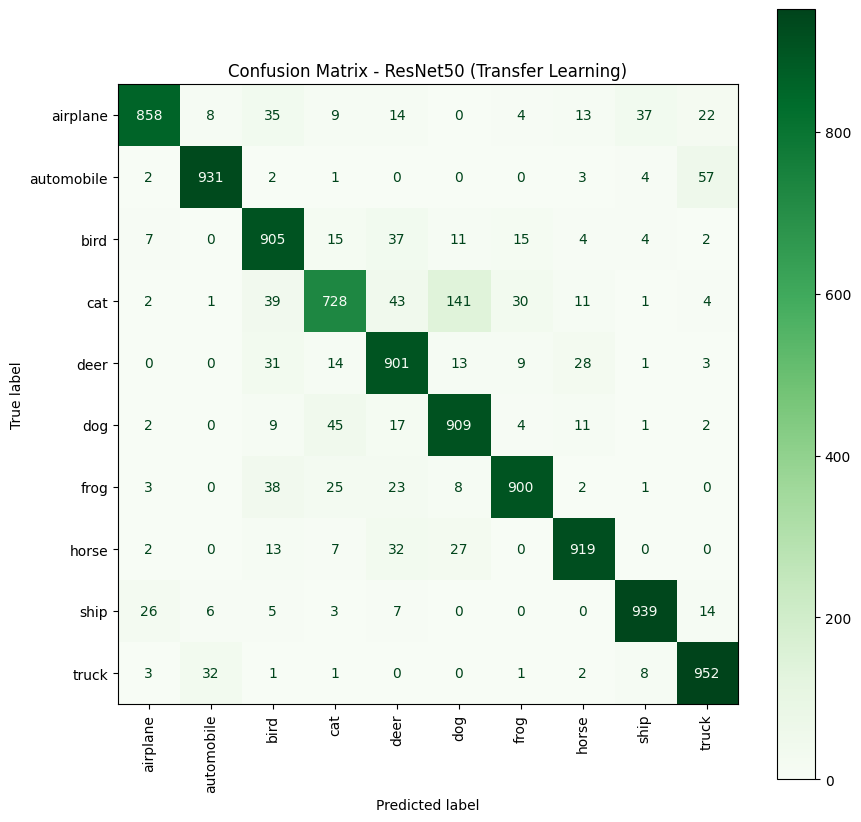

In [ ]:

# 1. הכנת נתוני הבדיקה עם העיבוד המתאים למודל המנצח
def preprocess_for_matrix(image, label):
    image = tf.image.resize(image, (224, 224))
    image = prep_func(image)
    return image, label

ds_matrix = ds_test_raw.map(preprocess_for_matrix).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 2. חילוץ התוויות האמיתיות וביצוע חיזויים (זה עשוי לקחת דקה בגלל גודל התמונות)
print(f"מחשב מטריצת בלבול עבור המודל המנצח: {best_model_name}...")
y_true_tl = np.concatenate([y for x, y in ds_matrix], axis=0)
predictions_tl = tl_best_model.predict(ds_matrix)
y_pred_tl = np.argmax(predictions_tl, axis=1)

# 3. יצירת התצוגה של המטריצה
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
disp_tl = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp_tl.plot(ax=ax, cmap=plt.cm.Greens, xticks_rotation='vertical')
plt.title(f'Confusion Matrix - {best_model_name} (Transfer Learning)')
plt.show()

מכין נתונים ומחשב מטריצה עבור: MobileNetV2...
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step


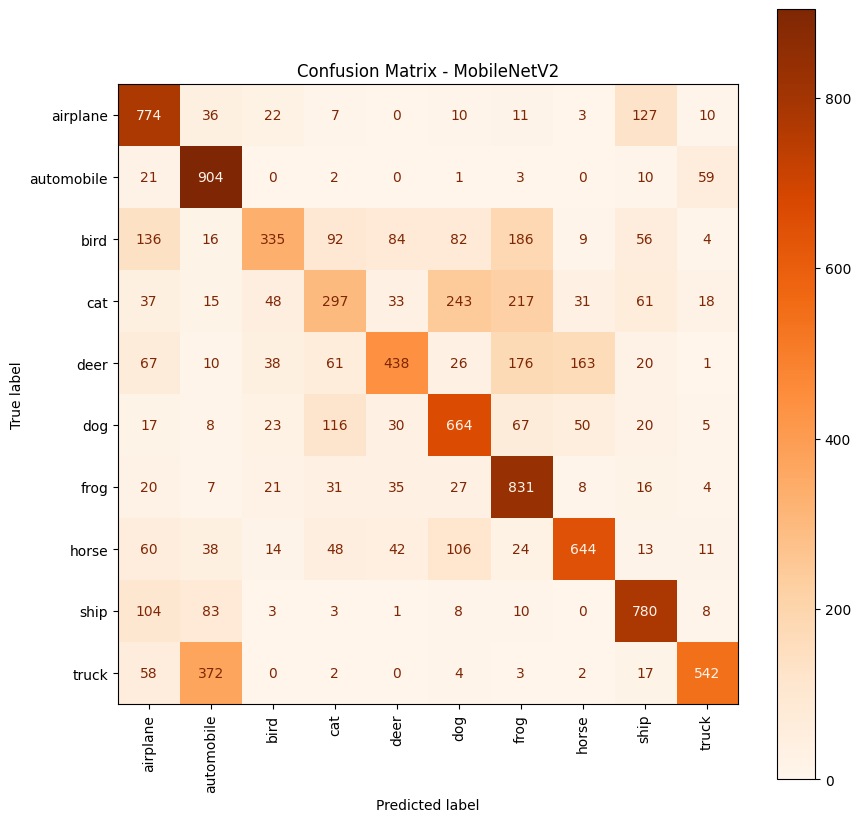

In [ ]:
# פונקציה גנרית להוצאת חיזויים ומטריצה - למניעת כפל קוד
def plot_tl_confusion_matrix(model_name, prep_function, color_map):
    print(f"מכין נתונים ומחשב מטריצה עבור: {model_name}...")

    # עיבוד הנתונים
    ds_temp = ds_test_raw.map(lambda x, y: (prep_function(tf.image.resize(x, (224, 224))), y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    # אם זה המודל המנצח, נשתמש במודל הקיים. אם לא, נשתמש ב-demo שכבר בנינו
    current_model = tl_best_model if model_name == best_model_name else tl_mobile_model

    y_true = np.concatenate([y for x, y in ds_temp], axis=0)
    y_pred = np.argmax(current_model.predict(ds_temp), axis=1)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap=color_map, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# הרצה עבור MobileNet (בצבע כתום)
plot_tl_confusion_matrix("MobileNetV2", mobilenet_preprocess, plt.cm.Oranges)

<div dir="rtl" style="font-family: Arial; line-height: 1.6; text-align: right;">
### ניתוח מטריצת הבלבול - MobileNetV2 לעומת המודלים הכבדים
<p>השוואת מטריצת הבלבול של MobileNetV2 (86%) למול המודל המנצח (91%) חושפת תובנות מעניינות על הפשרות בבניית מודלים:</p>
<ul>
<li><b>ריכוז השגיאות:</b> ניתן לראות שב-MobileNetV2 ה"רעש" מחוץ לאלכסון הראשי מעט גבוה יותר. בפרט, ישנו בלבול נפוץ יותר בין מחלקות דומות ויזואלית כמו <b>Cat</b> ו-<b>Dog</b> או <b>Truck</b> ו-<b>Automobile</b>.</li>
<li><b>יכולת הפרדה:</b> המודלים הכבדים יותר (ResNet/EfficientNet) מצליחים להבחין טוב יותר בפרטים קטנים (Fine-grained features), בעוד ש-MobileNet, בשל היותו מודל "רזה" המיועד ליעילות חישובית, נוטה להכליל יתר על המידה במקרים גבוליים.</li>
<li><b>יציבות במחלקות קלות:</b> מעניין לציין שבמחלקות "קלות" יחסית כמו <b>Ship</b> או <b>Airplane</b>, גם המודל הפחות טוב מציג ביצועים כמעט מושלמים, מה שמעיד שהמגבלה שלו היא בעיקר בייצוג אובייקטים בעלי מורכבות ויזואלית גבוהה.</li>
</ul>
<p><b>מסקנה:</b> למרות ש-MobileNetV2 הוא "החלש" מבין השלושה, מטריצת הבלבול שלו עדיין נקייה בהרבה מזו של המודל שבנינו מאפס, מה שמדגיש שגם למידת העברה "קלה" עדיפה משמעותית על אימון רשת בסיסית מאפס.</p>
</div>

In [ ]:
# Finding the winning model from our results dictionary
best_model_name = max(results, key=results.get)
best_model_acc = results[best_model_name]

print(f"The model selected for visual display is the winner: {best_model_name} (Accuracy: {best_model_acc:.2f})")

# Selecting the preprocessing function and base model according to the winner
if best_model_name == "MobileNetV2":
    base_class = MobileNetV2
    prep_func = mobilenet_preprocess
elif best_model_name == "ResNet50":
    base_class = ResNet50
    prep_func = resnet_preprocess
else:
    base_class = EfficientNetB0
    prep_func = efficientnet_preprocess

# Preparing the data for the winning model
def format_for_best(image, label):
    image = tf.image.resize(image, (224, 224))
    image = prep_func(image)
    return image, label

train_demo = ds_train_raw.map(format_for_best, num_parallel_calls=AUTOTUNE).batch(128).prefetch(AUTOTUNE)

# Building the winning model
demo_base = base_class(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
demo_base.trainable = False

tl_best_model = keras.Sequential([
    demo_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

tl_best_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

print("Training the winning model (one epoch) for prediction display...")
tl_best_model.fit(train_demo, epochs=1)

print("Generating display...")
plt.figure(figsize=(12, 12))

# Fetching 9 images from the test data
for images_raw, labels in ds_test_raw.batch(9).take(1):

    # Preprocessing the images specifically for the winning model
    images_processed = prep_func(tf.image.resize(images_raw, (224, 224)))
    preds = tl_best_model.predict(images_processed)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images_raw[i].numpy() / 255.0)

        color = 'green' if labels[i] == pred_labels[i] else 'red'
        plt.title(f"True: {class_names[labels[i]]}\nPredicted: {class_names[pred_labels[i]]}", color=color)
        plt.axis("off")

plt.suptitle(f"Prediction Results for the Leading Model - {best_model_name}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The model selected for visual display is the winner: ResNet50 (Accuracy: 0.91)
Training the winning model (one epoch) for prediction display...
352/391 ━━━━━━━━━━━━━━━━━━━━ 14s 364ms/step - accuracy: 0.8075 - loss: 0.5551